# Label Creation

This notebook creates the target variable (`label`) for supervised machine learning.

Employees listed in the CERT `insiders.csv` file for dataset **6.2** are labeled as insiders (`1`), while all remaining employees are labeled as normal (`0`).

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
FEATURE_PATH = Path("../DATA/features")
ANSWER_PATH = Path("../DATA/raw/answers")

merged_data = pd.read_csv(
    FEATURE_PATH / "merged_features.csv"
)

insiders = pd.read_csv(
    ANSWER_PATH / "insiders.csv"
)

In [3]:
# Extract R6.2 Insider Users
r62_insiders = insiders[
    insiders["dataset"] == 6.2
]

malicious_users = r62_insiders["user"].unique()

print("Number of Insider Users:", len(malicious_users))
print(malicious_users)

Number of Insider Users: 5
<ArrowStringArray>
['ACM2278', 'CMP2946', 'PLJ1771', 'CDE1846', 'MBG3183']
Length: 5, dtype: str


# Create the Target Variable (Label)

Employees identified as insiders in the CERT R6.2 dataset are assigned a label of **1**.

All other employees are assigned a label of **0**.

In [4]:
merged_data["label"] = merged_data["user"].isin(malicious_users).astype(int)

merged_data.head()

,user,total_events,total_logons,total_logoffs,after_hours_events,weekend_events,unique_pcs_x,working_days,avg_events_per_day,first_login_hour,...,after_hours_http_count,weekend_http_count,unique_urls,unique_http_pcs,O,C,E,A,N,label
0,AAB0162,711,355,356,705.0,0.0,1,356,1.997191,7,...,4277,0,144,1,45,36,33,15,33,0
1,AAB0398,712,356,356,356.0,0.0,1,356,2.000000,6,...,7128,0,351,1,16,38,16,26,34,0
2,AAC0610,1052,665,387,222.0,5.0,1,360,2.922222,0,...,240,0,267,1,46,35,50,42,31,0
3,AAC0668,712,356,356,158.0,0.0,1,356,2.000000,7,...,320,0,227,1,38,48,37,38,37,0
4,AAC3270,712,356,356,0.0,0.0,1,356,2.000000,8,...,0,0,60,1,26,37,42,45,30,0


In [5]:
# Verify Label Distribution
label_counts = merged_data["label"].value_counts()

print(label_counts)

label
0    3995
1       5
Name: count, dtype: int64


In [6]:
# Display Class Distribution Percentage
label_percentage = (
    merged_data["label"]
    .value_counts(normalize=True)
    * 100
)

print(label_percentage)

label
0    99.875
1     0.125
Name: proportion, dtype: float64


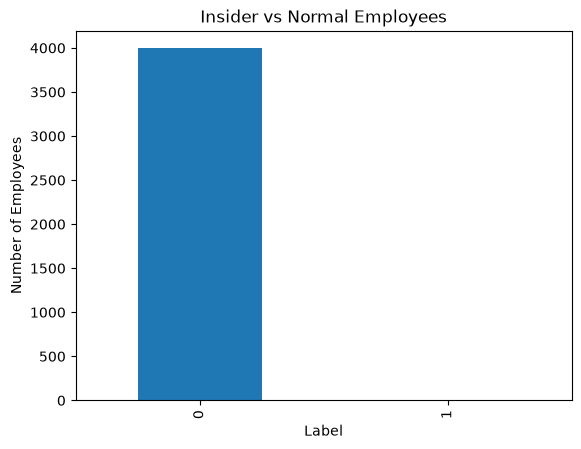

In [7]:
# Visualize Label Distribution
import matplotlib.pyplot as plt

merged_data["label"].value_counts().plot(
    kind="bar"
)

plt.title("Insider vs Normal Employees")
plt.xlabel("Label")
plt.ylabel("Number of Employees")
plt.show()

# Verify Label Integrity

Before saving the dataset, verify that every employee has a valid label and that there are no missing values.

In [8]:
merged_data["label"].isnull().sum()

np.int64(0)

In [9]:
# Save the Labeled Dataset
PROCESSED_PATH = Path("../DATA/processed")
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

merged_data.to_csv(
    PROCESSED_PATH / "labeled_dataset.csv",
    index=False
)

In [10]:
# Verify the Saved Dataset
labeled_data = pd.read_csv(
    "../DATA/processed/labeled_dataset.csv"
)

labeled_data.head()

,user,total_events,total_logons,total_logoffs,after_hours_events,weekend_events,unique_pcs_x,working_days,avg_events_per_day,first_login_hour,...,after_hours_http_count,weekend_http_count,unique_urls,unique_http_pcs,O,C,E,A,N,label
0,AAB0162,711,355,356,705.0,0.0,1,356,1.997191,7,...,4277,0,144,1,45,36,33,15,33,0
1,AAB0398,712,356,356,356.0,0.0,1,356,2.000000,6,...,7128,0,351,1,16,38,16,26,34,0
2,AAC0610,1052,665,387,222.0,5.0,1,360,2.922222,0,...,240,0,267,1,46,35,50,42,31,0
3,AAC0668,712,356,356,158.0,0.0,1,356,2.000000,7,...,320,0,227,1,38,48,37,38,37,0
4,AAC3270,712,356,356,0.0,0.0,1,356,2.000000,8,...,0,0,60,1,26,37,42,45,30,0


In [11]:
# Final Dataset Summary
print("Final Dataset Shape:", labeled_data.shape)

print("\nColumns:")
print(labeled_data.columns.tolist())

print("\nLabel Distribution:")
print(labeled_data["label"].value_counts())

Final Dataset Shape: (4000, 49)

Columns:
['user', 'total_events', 'total_logons', 'total_logoffs', 'after_hours_events', 'weekend_events', 'unique_pcs_x', 'working_days', 'avg_events_per_day', 'first_login_hour', 'last_logout_hour', 'work_duration_hours', 'total_device_events', 'total_connects', 'total_disconnects', 'after_hours_device_events', 'weekend_device_events', 'total_email_events', 'total_email_sent', 'after_hours_email_count', 'weekend_email_count', 'attachment_email_count', 'average_email_size_kb', 'average_recipient_count', 'total_file_events', 'file_open_count', 'file_copy_count', 'file_write_count', 'file_delete_count', 'files_to_removable_media', 'files_from_removable_media', 'unique_files', 'unique_pcs_y', 'after_hours_file_activity', 'weekend_file_count', 'total_http_events', 'http_visit_count', 'http_download_count', 'http_upload_count', 'after_hours_http_count', 'weekend_http_count', 'unique_urls', 'unique_http_pcs', 'O', 'C', 'E', 'A', 'N', 'label']

Label Distribu